In [8]:
import pandas as pd
import thebeat
import os
import matplotlib.pyplot as plt
import numpy as np

In [9]:
# Load ITIs df
ITIs = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs.csv'))
ITIs_bytrial = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'ITIs_bytrial.csv'))
pp_measures = pd.read_csv(os.path.join('data', 'experiment', 'processed', 'pp_measures.csv'))

In [10]:
# Find sequence id's of trials with highest and lowest ratio pref
highest_simpleratio_introduced = ITIs_bytrial.nlargest(18, 'simple_ratio_introduced').sequence_id.values
lowest_simpleratio_introduced = ITIs_bytrial.nsmallest(18, 'simple_ratio_introduced').sequence_id.values

# Find sequence id's of trials with middle ratio pref
zero_simpleratio_introduced = ITIs_bytrial[ITIs_bytrial['simple_ratio_introduced'] == 0].sample(18).sequence_id.values

# Get ITIs of 9 sequences with the highest and lowest edit distance
highest_simpleratio_introduced_df = ITIs[ITIs['sequence_id'].isin(highest_simpleratio_introduced)]
zero_simpleratio_introduced_df = ITIs[ITIs['sequence_id'].isin(zero_simpleratio_introduced)]
lowest_simpleratio_introduced_df = ITIs[ITIs['sequence_id'].isin(lowest_simpleratio_introduced)]


# Most simple ratios discarded (i.e. negative introduced)

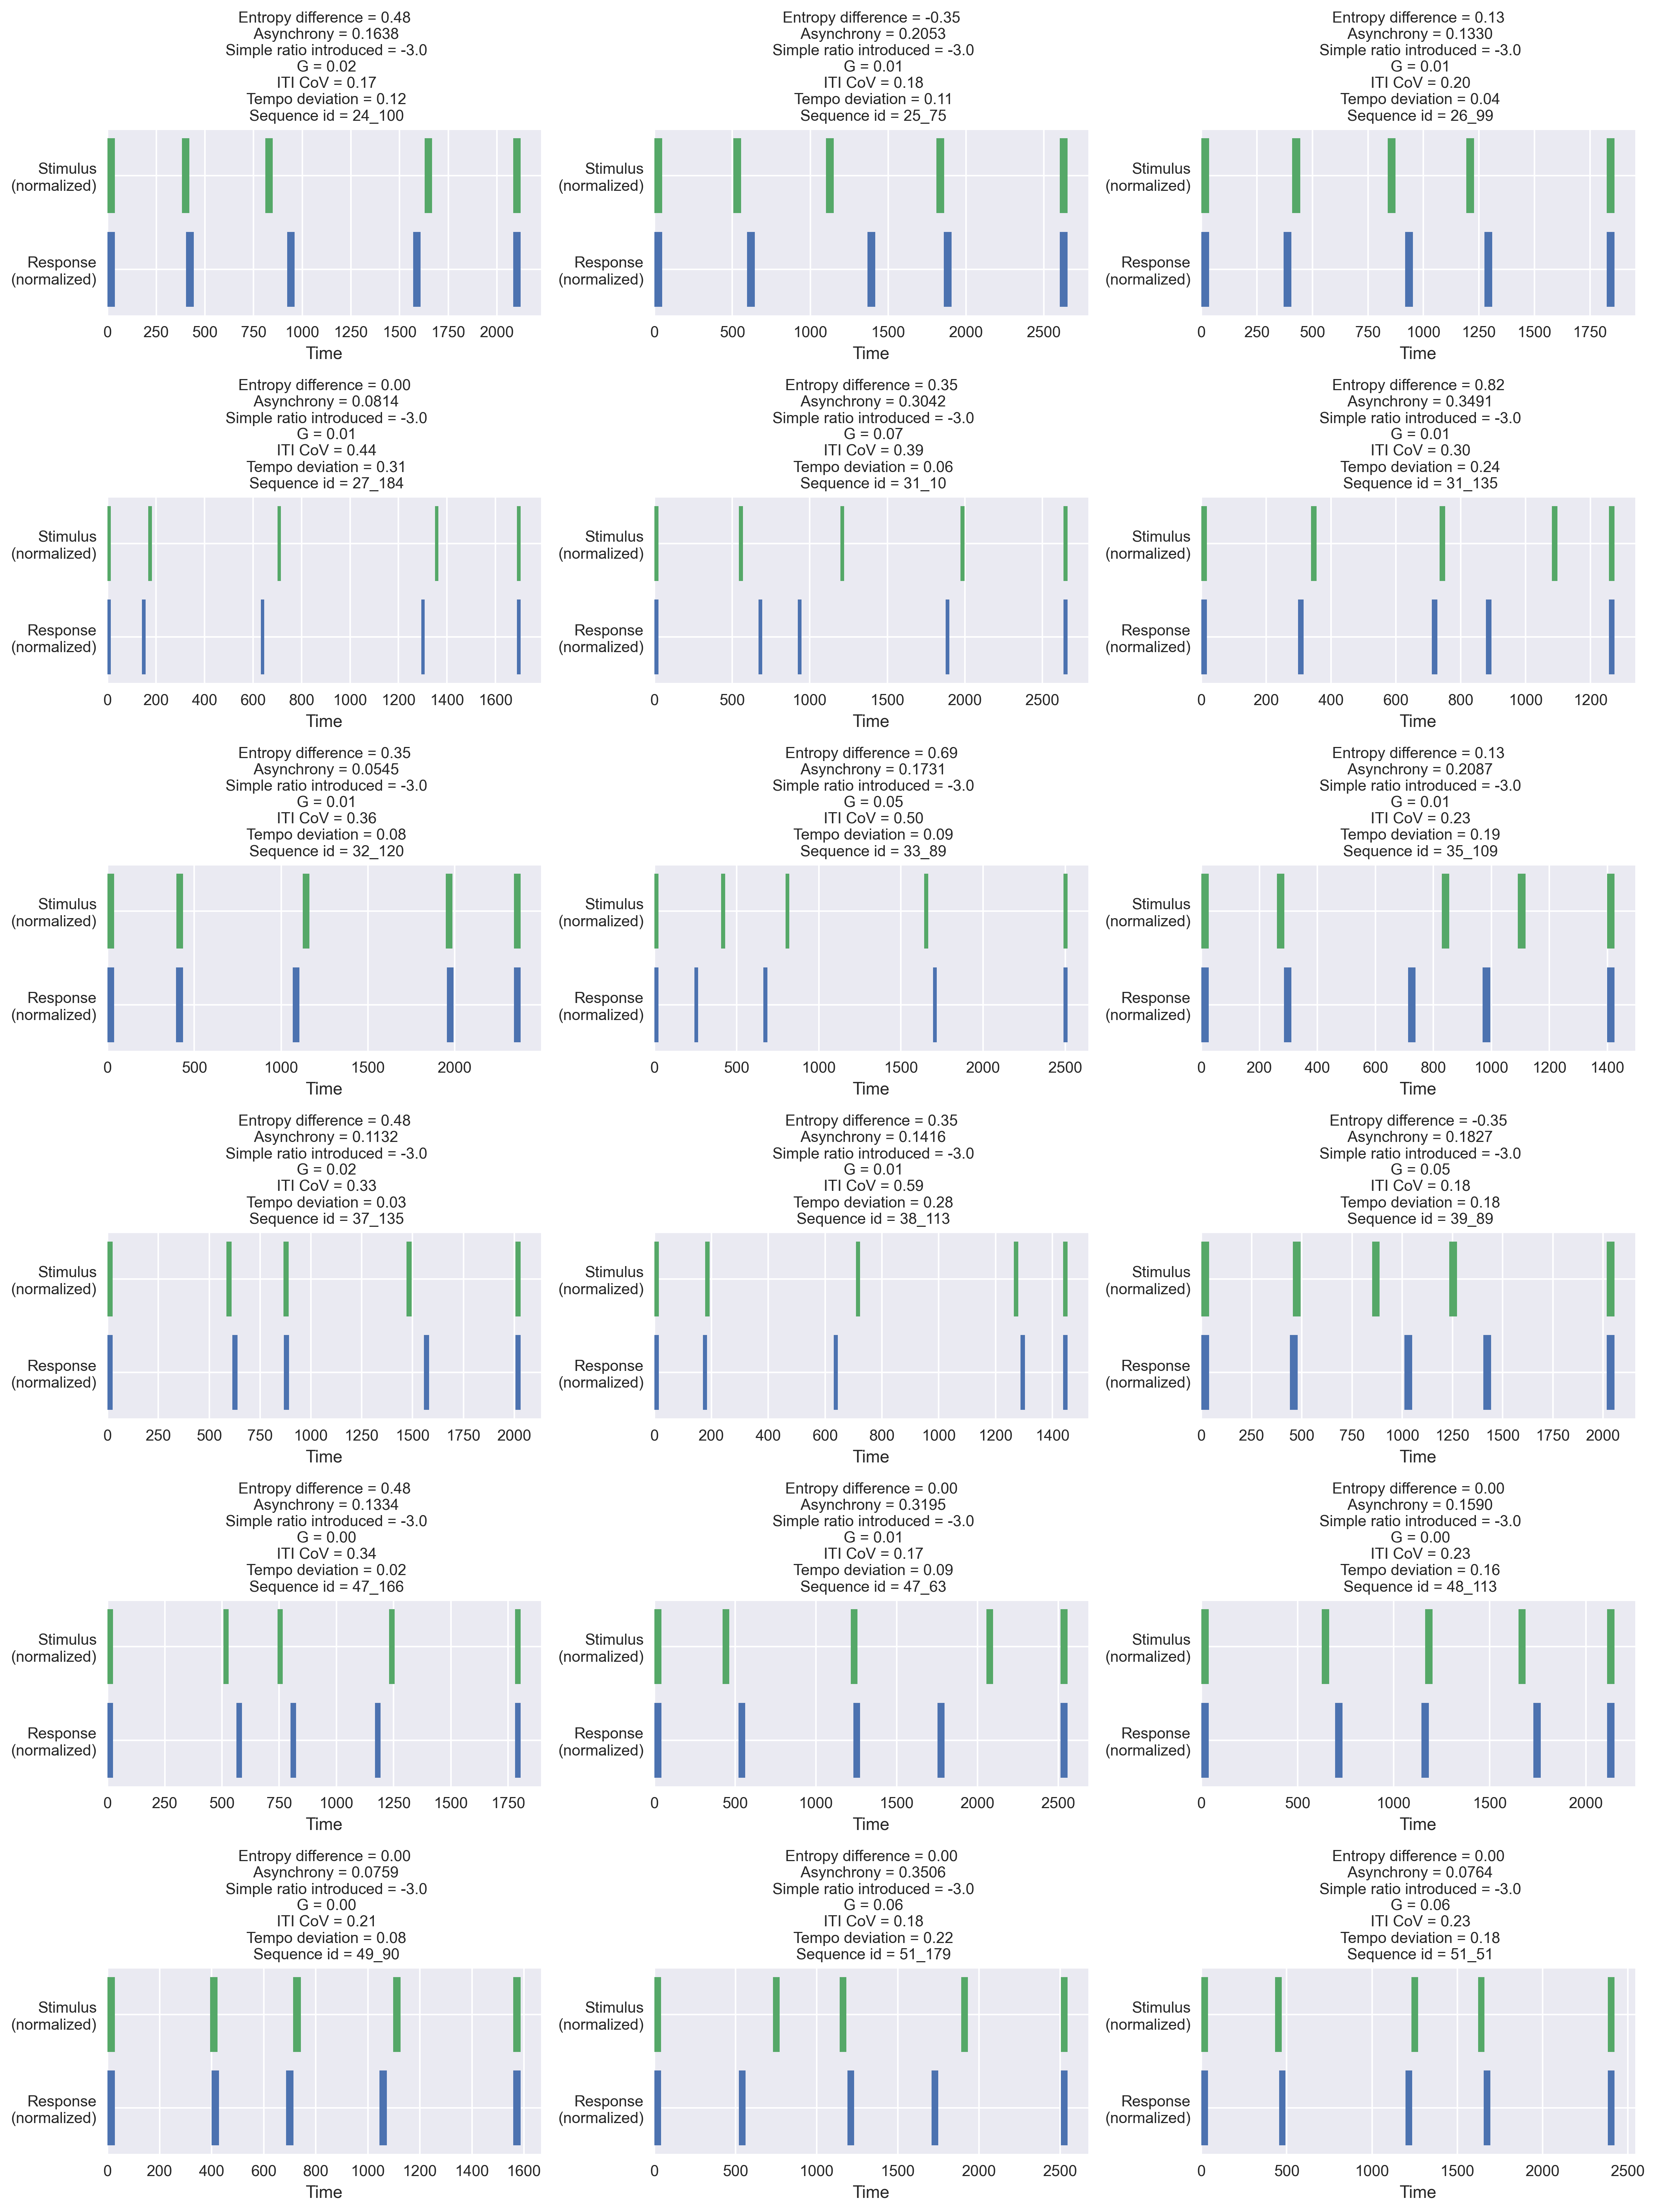

In [11]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in lowest_simpleratio_introduced_df.groupby('sequence_id'):
    resp_seq = thebeat.Sequence(seq_df.resp_iti_norm.values)
    stim_seq = thebeat.Sequence(seq_df.stim_ioi.values)
    thebeat.visualization.plot_multiple_sequences([stim_seq, resp_seq], y_axis_labels=['Stimulus\n(normalized)', 'Response\n(normalized)'],
                                                  ax = axs.flat[count],
    title=
f"Entropy difference = {seq_df.entropy_diff_norm_q.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.4f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}\n \
ITI CoV = {seq_df.iti_cov_norm.values[0]:.2f}\n \
Tempo deviation = {np.abs(1 - seq_df.tempo_ratio_resp_to_stim.values[0]):.2f}\n \
Sequence id = {seq_id}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)

# No difference in number of simple integer ratios

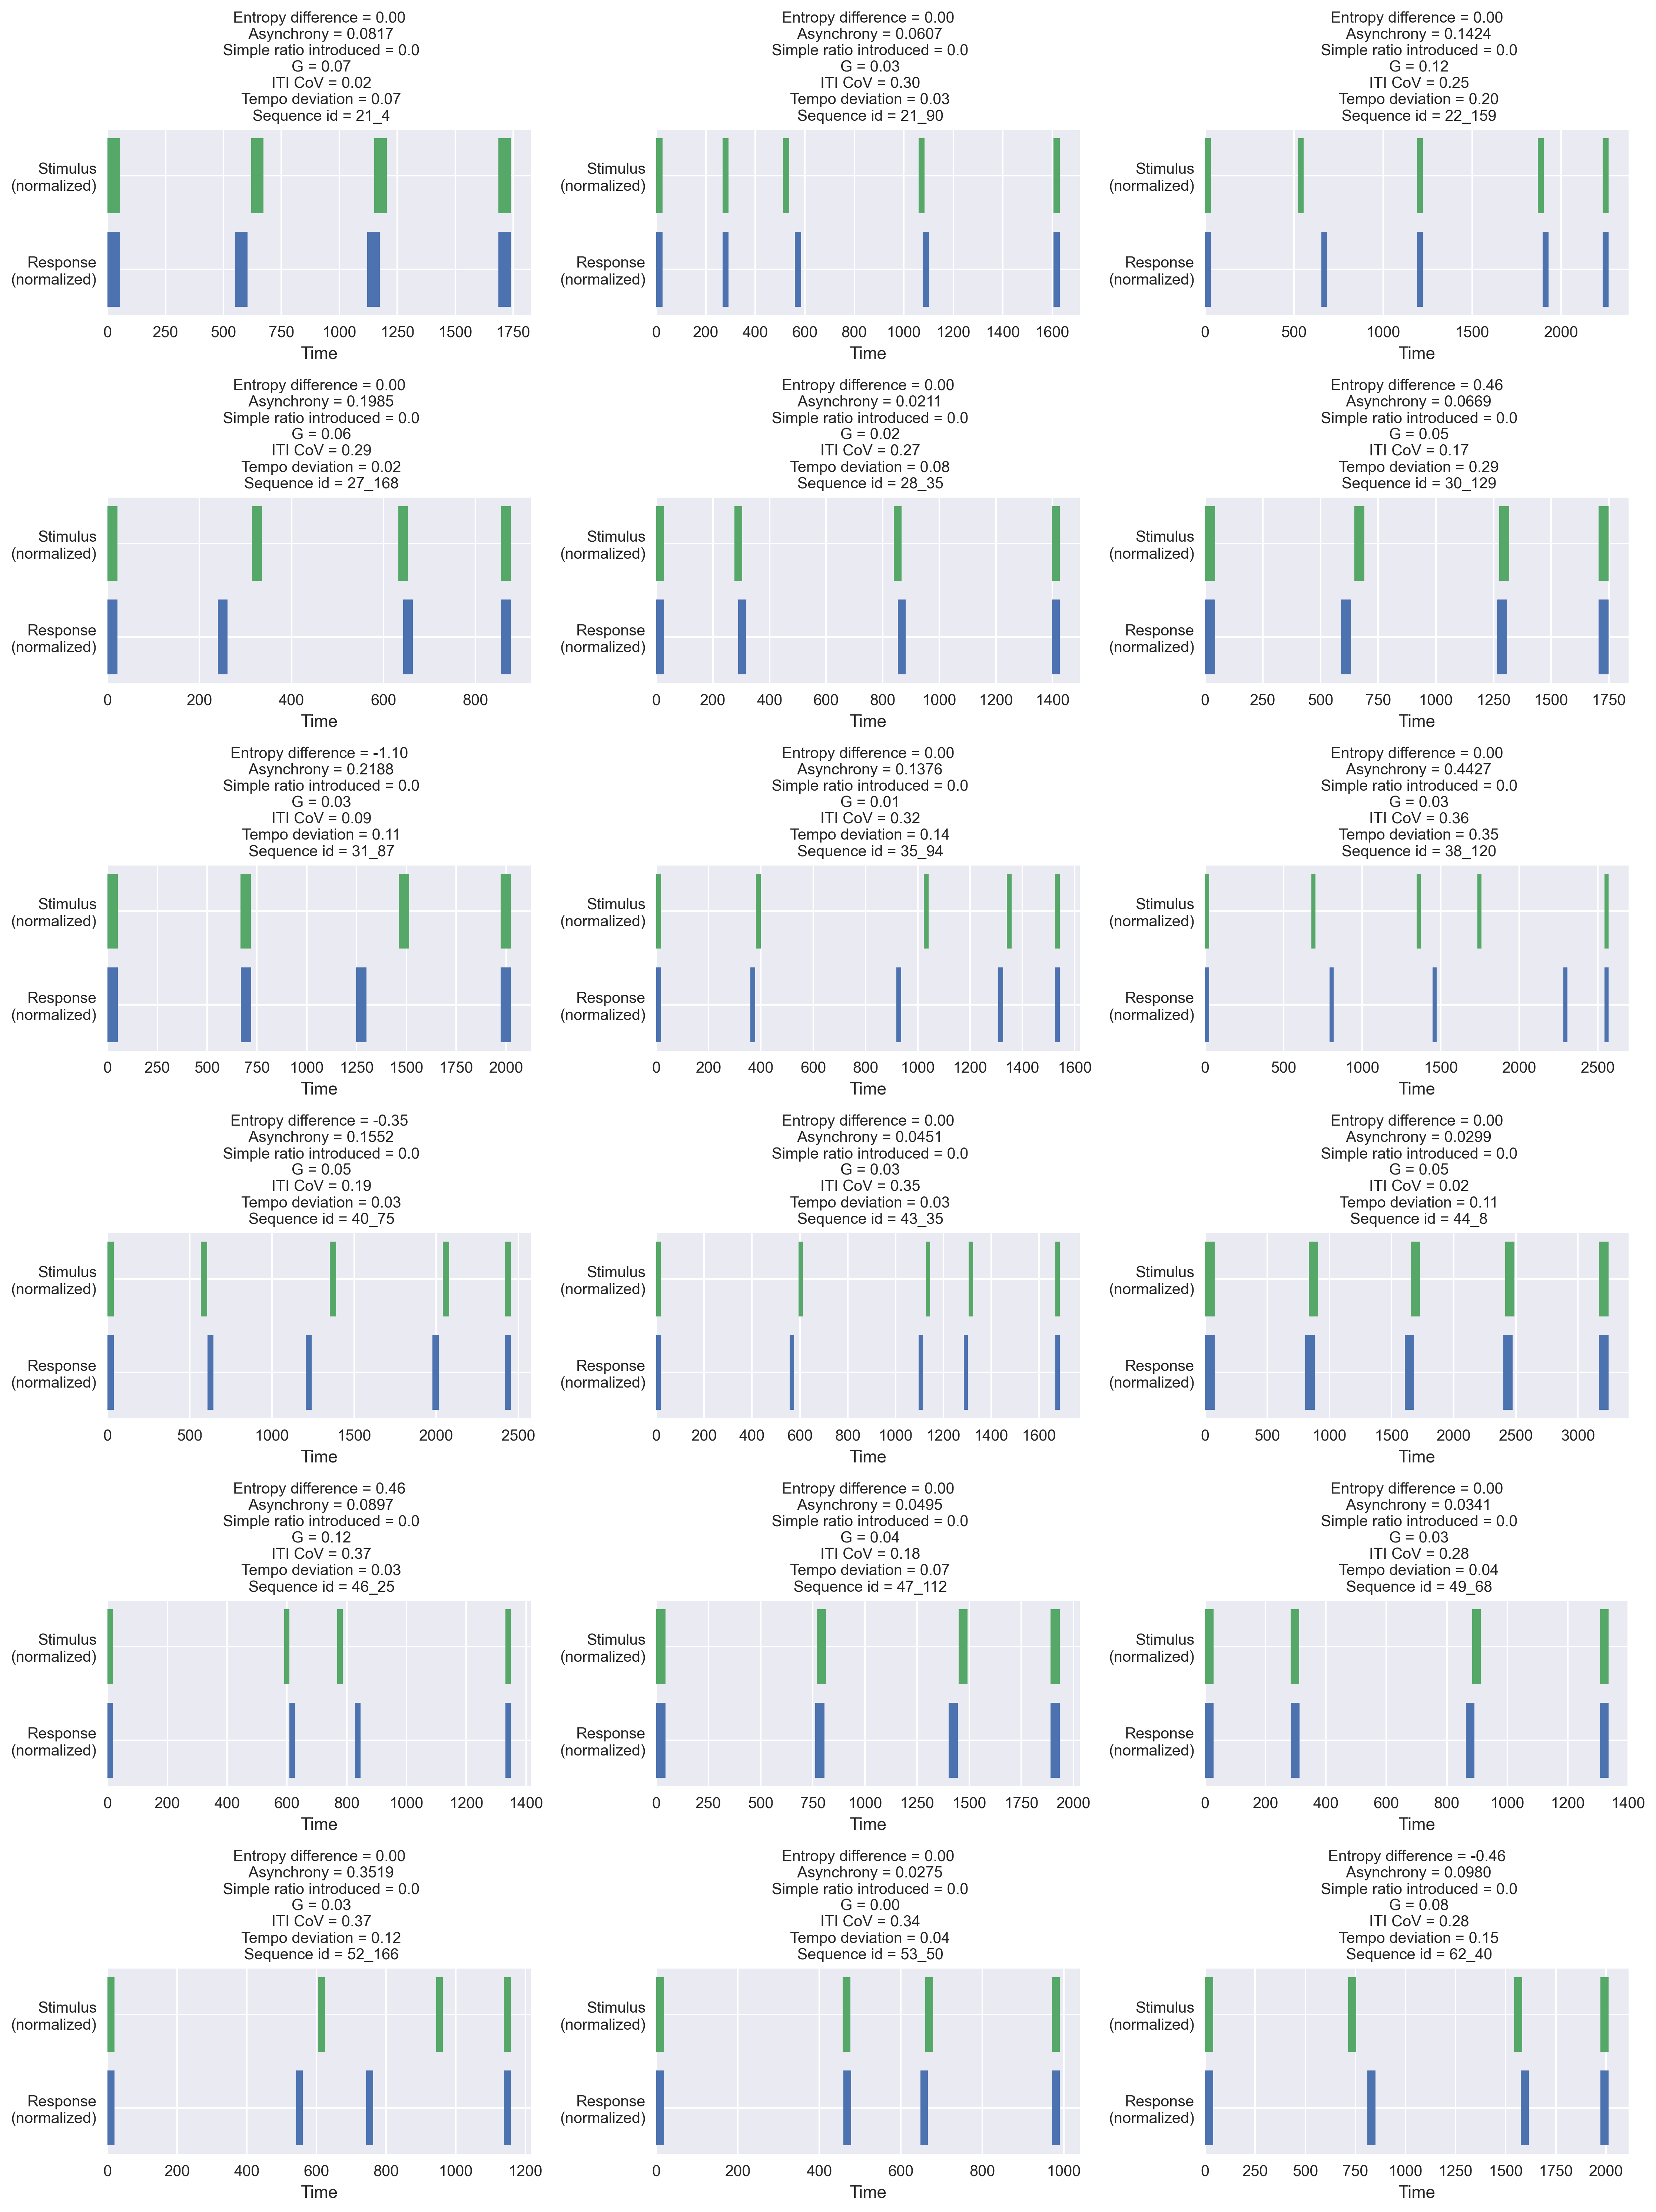

In [12]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in zero_simpleratio_introduced_df.groupby('sequence_id'):
    resp_seq = thebeat.Sequence(seq_df.resp_iti_norm.values)
    stim_seq = thebeat.Sequence(seq_df.stim_ioi.values)
    thebeat.visualization.plot_multiple_sequences([stim_seq, resp_seq], y_axis_labels=['Stimulus\n(normalized)', 'Response\n(normalized)'],
                                                  ax = axs.flat[count],
    title=
f"Entropy difference = {seq_df.entropy_diff_norm_q.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.4f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}\n \
ITI CoV = {seq_df.iti_cov_norm.values[0]:.2f}\n \
Tempo deviation = {np.abs(1 - seq_df.tempo_ratio_resp_to_stim.values[0]):.2f}\n \
Sequence id = {seq_id}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)

# Highest number of simple ratios introduced

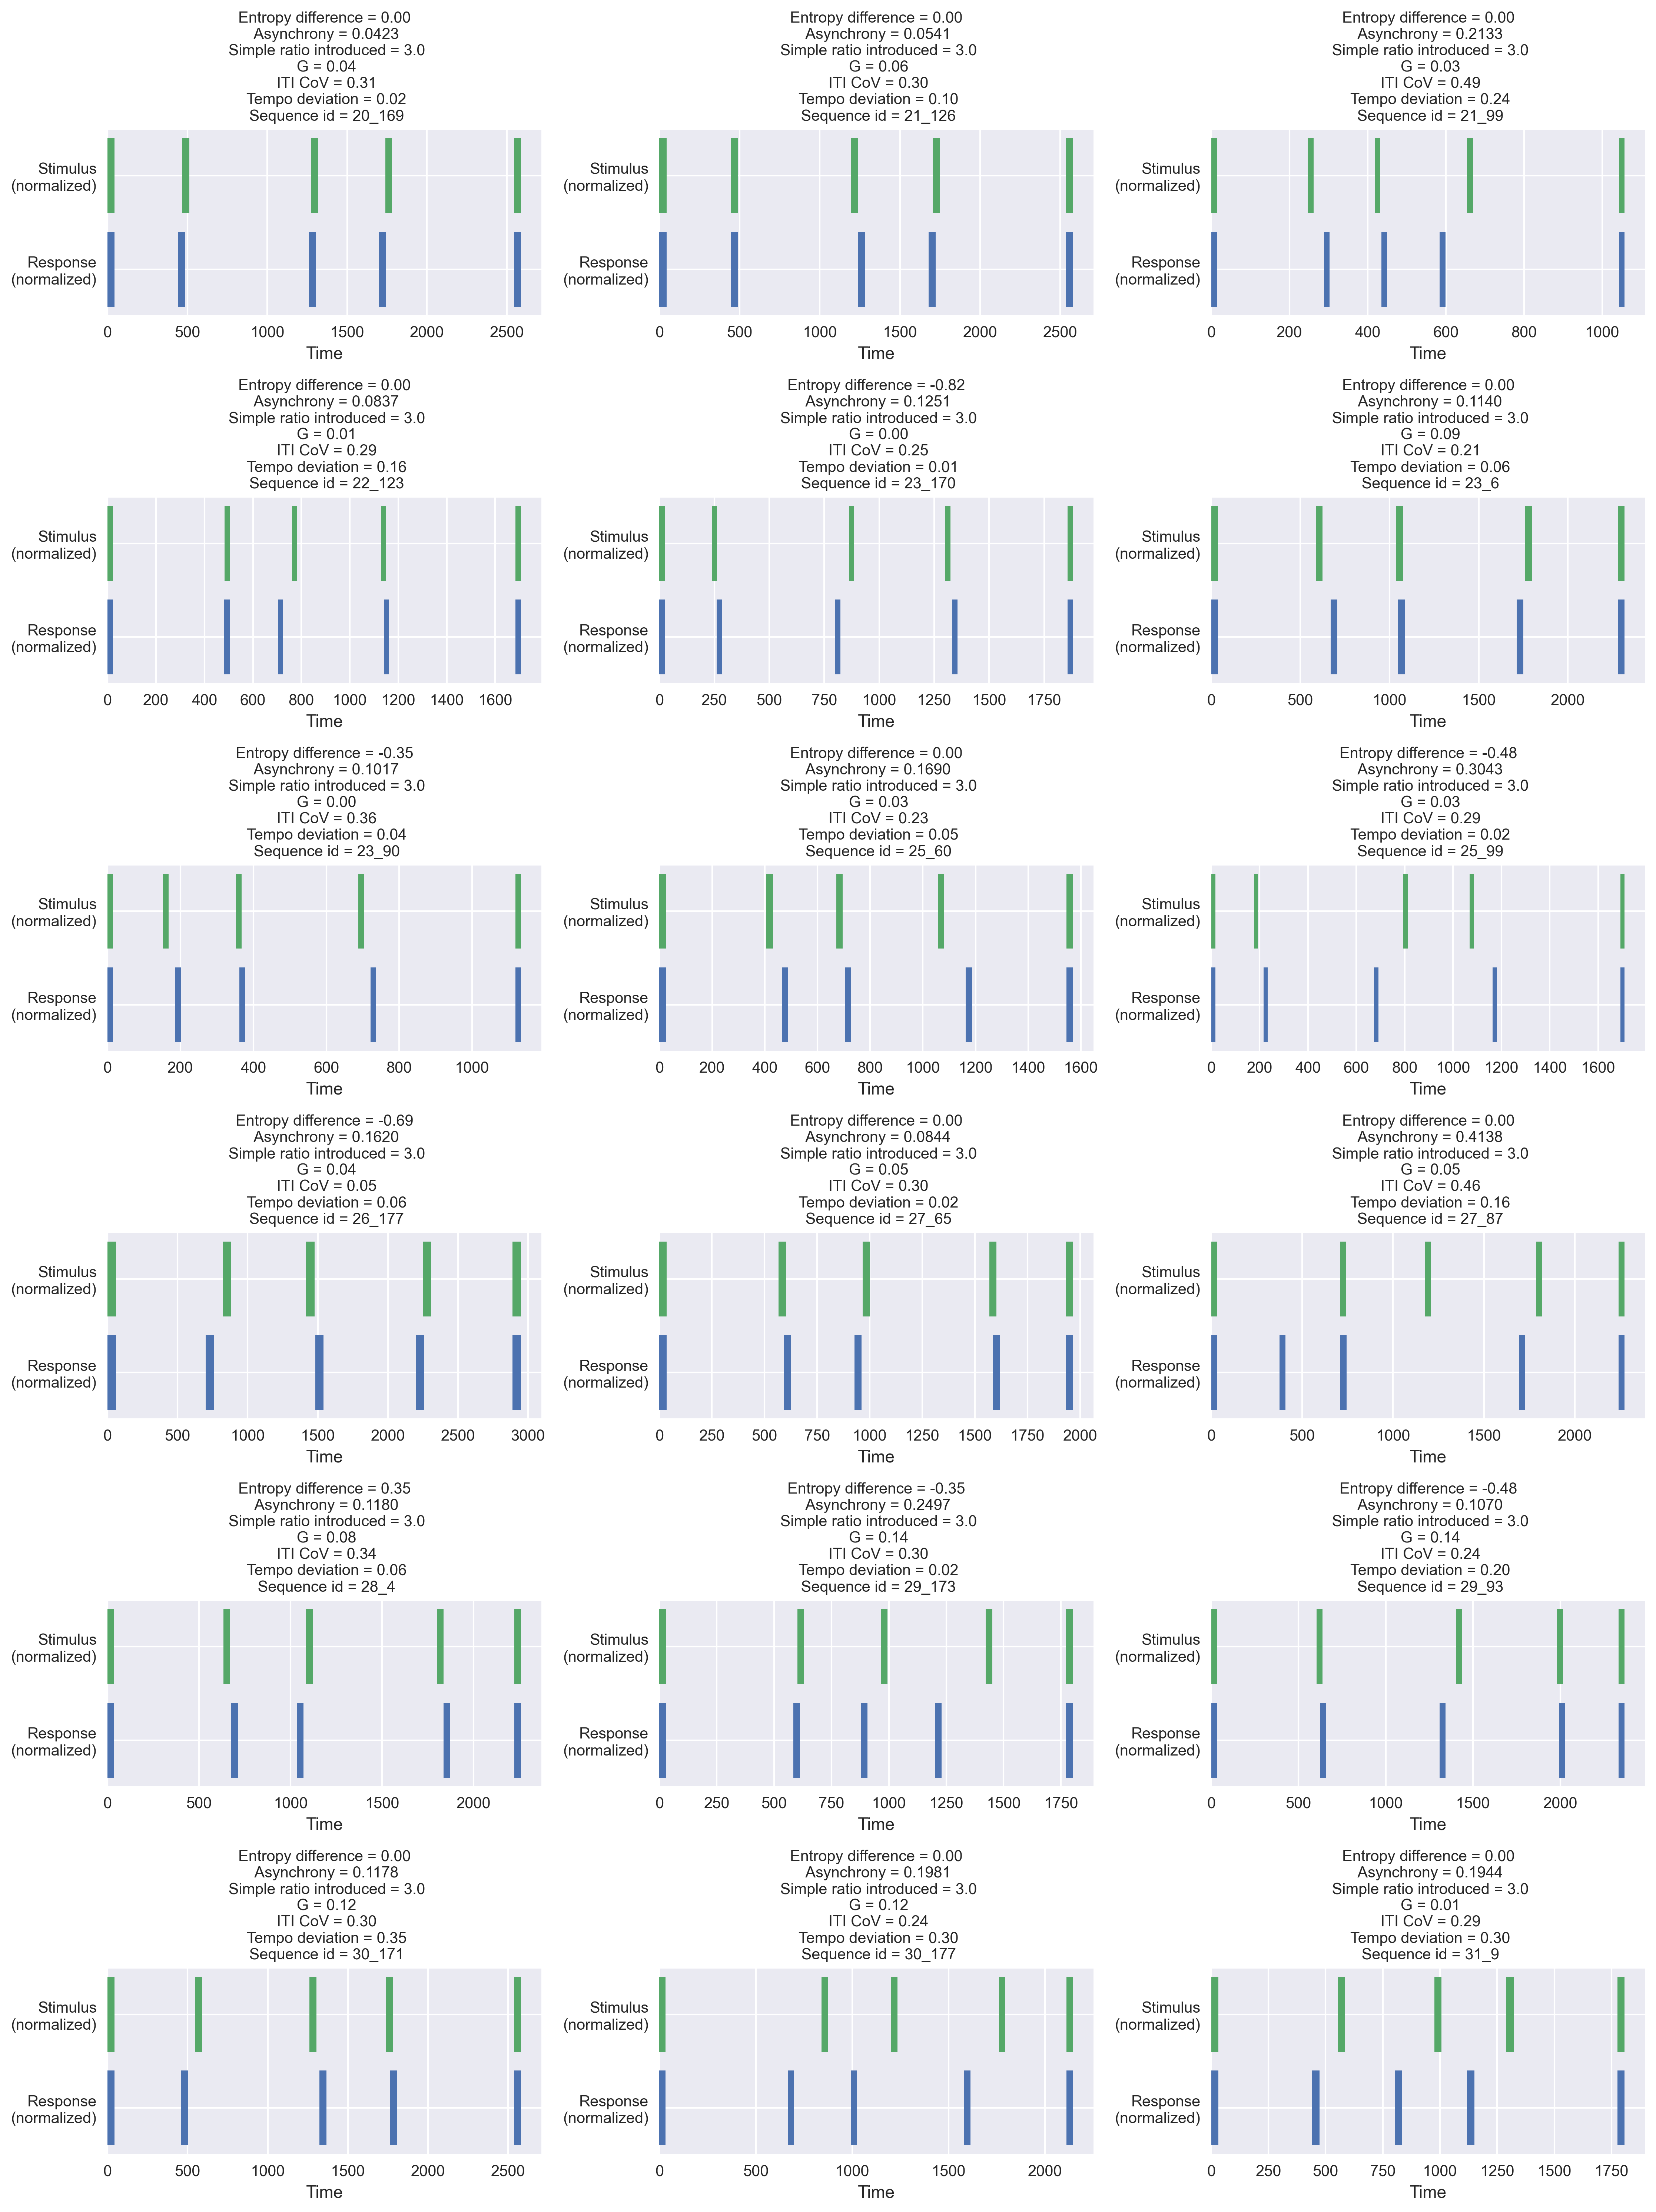

In [13]:
# Plot ITIs by sequence_id

plt.style.use('seaborn-v0_8')

fig, axs = plt.subplots(6, 3, figsize=(15, 20), tight_layout=True, dpi=300)

count = 0

for seq_id, seq_df in highest_simpleratio_introduced_df.groupby('sequence_id'):
    resp_seq = thebeat.Sequence(seq_df.resp_iti_norm.values)
    stim_seq = thebeat.Sequence(seq_df.stim_ioi.values)
    thebeat.visualization.plot_multiple_sequences([stim_seq, resp_seq], y_axis_labels=['Stimulus\n(normalized)', 'Response\n(normalized)'],
                                                  ax = axs.flat[count],
    title=
f"Entropy difference = {seq_df.entropy_diff_norm_q.values[0]:.2f}\n \
Asynchrony = {ITIs_bytrial[ITIs_bytrial.sequence_id == seq_id].asynchrony_norm_abs_trialsum.values[0]:.4f}\n \
Simple ratio introduced = {seq_df.simple_ratio_introduced.values[0]}\n \
G = {seq_df.G_resp.values[0]:.2f}\n \
ITI CoV = {seq_df.iti_cov_norm.values[0]:.2f}\n \
Tempo deviation = {np.abs(1 - seq_df.tempo_ratio_resp_to_stim.values[0]):.2f}\n \
Sequence id = {seq_id}")
    

    count += 1

# Change font size of title in all subplots
for ax in axs.flat:
    ax.title.set_fontsize(10)